In [1]:
# 单元格1：导入库和设置环境
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

print("=== Simple OpenCV Image Processing ===")
print(f"OpenCV Version: {cv2.__version__}")

=== Simple OpenCV Image Processing ===
OpenCV Version: 4.8.1


In [2]:
# 单元格2：创建测试图像
def create_simple_image():
    """创建一个简单的测试图像"""
    # 创建400x500的白色背景
    image = np.ones((400, 500, 3), dtype=np.uint8) * 255

    # 绘制一个蓝色矩形
    cv2.rectangle(image, (50, 50), (200, 150), (255, 0, 0), 3)

    # 绘制一个红色圆形
    cv2.circle(image, (350, 200), 50, (0, 0, 255), -1)

    # 绘制一条绿色对角线
    cv2.line(image, (100, 300), (400, 300), (0, 255, 0), 5)

    # 添加文字
    cv2.putText(image, 'OpenCV Demo', (150, 350),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 2)

    return image

# 生成图像
test_img = create_simple_image()
print(f"Image created: {test_img.shape}")
print(f"Min value: {test_img.min()}, Max value: {test_img.max()}")

Image created: (400, 500, 3)
Min value: 0, Max value: 255


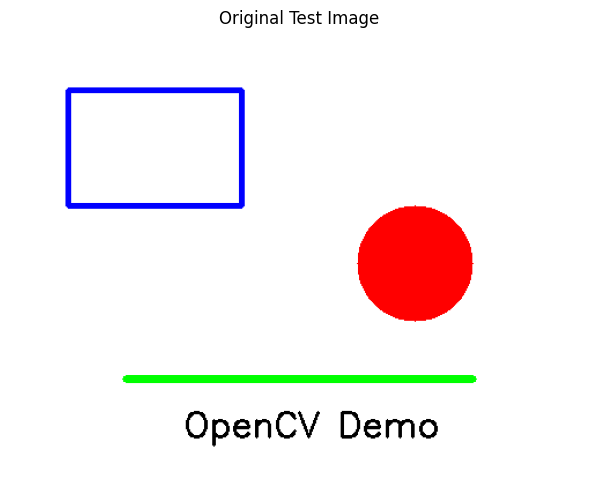

In [3]:
# 单元格3：显示原始图像
def show_image(image, title="Image"):
    """显示图像"""
    # 如果是彩色图像，转换BGR到RGB
    if len(image.shape) == 3:
        display_img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    else:
        display_img = image

    plt.figure(figsize=(8, 6))
    plt.imshow(display_img)
    plt.title(title)
    plt.axis('off')
    plt.show()

show_image(test_img, "Original Test Image")

In [4]:
# 单元格4：基本图像处理
print("=== Basic Image Processing ===")

# 1. 转换为灰度
gray_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2GRAY)
print(f"1. Grayscale conversion done. Shape: {gray_img.shape}")

# 2. 边缘检测
edges = cv2.Canny(gray_img, 100, 200)
print(f"2. Edge detection done. Edge pixels: {np.sum(edges > 0)}")

# 3. 高斯模糊
blurred = cv2.GaussianBlur(test_img, (15, 15), 0)
print(f"3. Gaussian blur applied.")

# 4. 图像二值化
_, binary = cv2.threshold(gray_img, 127, 255, cv2.THRESH_BINARY)
print(f"4. Binary thresholding done.")

=== Basic Image Processing ===
1. Grayscale conversion done. Shape: (400, 500)
2. Edge detection done. Edge pixels: 2975
3. Gaussian blur applied.
4. Binary thresholding done.


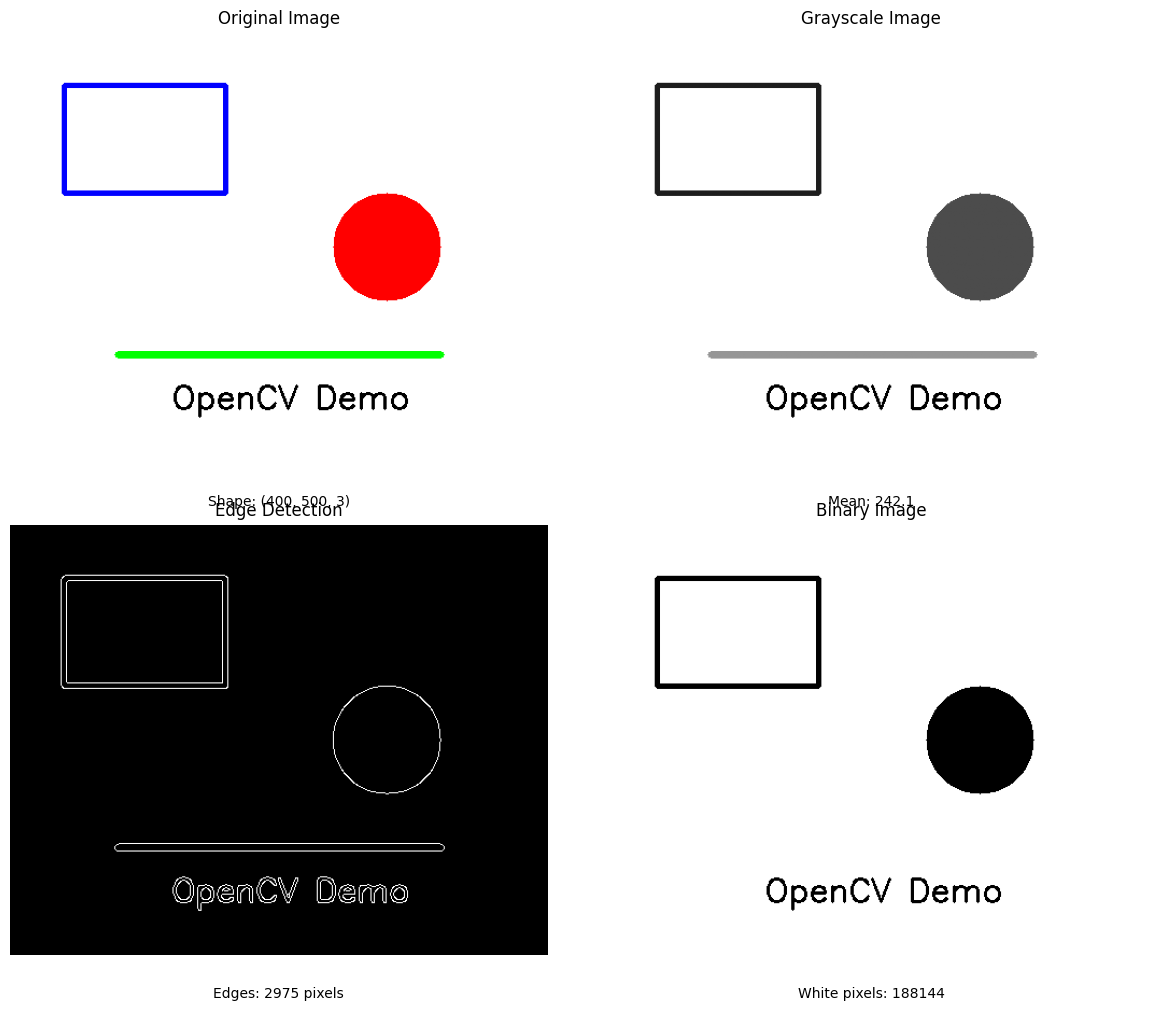

In [5]:
# 单元格5：显示处理结果
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 原始图像
axes[0, 0].imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')
axes[0, 0].text(0.5, -0.1, f'Shape: {test_img.shape}',
                transform=axes[0, 0].transAxes, ha='center')

# 灰度图像
axes[0, 1].imshow(gray_img, cmap='gray')
axes[0, 1].set_title('Grayscale Image')
axes[0, 1].axis('off')
axes[0, 1].text(0.5, -0.1, f'Mean: {gray_img.mean():.1f}',
                transform=axes[0, 1].transAxes, ha='center')

# 边缘检测
axes[1, 0].imshow(edges, cmap='gray')
axes[1, 0].set_title('Edge Detection')
axes[1, 0].axis('off')
axes[1, 0].text(0.5, -0.1, f'Edges: {np.sum(edges > 0)} pixels',
                transform=axes[1, 0].transAxes, ha='center')

# 二值化图像
axes[1, 1].imshow(binary, cmap='gray')
axes[1, 1].set_title('Binary Image')
axes[1, 1].axis('off')
axes[1, 1].text(0.5, -0.1, f'White pixels: {np.sum(binary > 0)}',
                transform=axes[1, 1].transAxes, ha='center')

plt.tight_layout()
plt.show()

In [6]:
# 单元格6：更多处理操作
print("=== Additional Processing ===")

# 1. 图像旋转
(h, w) = test_img.shape[:2]
center = (w // 2, h // 2)
rotation_matrix = cv2.getRotationMatrix2D(center, 45, 1.0)  # 旋转45度
rotated = cv2.warpAffine(test_img, rotation_matrix, (w, h))

# 2. 图像缩放
resized = cv2.resize(test_img, (250, 200))

# 3. 图像反转
flipped_h = cv2.flip(test_img, 1)  # 水平翻转
flipped_v = cv2.flip(test_img, 0)  # 垂直翻转

print("Additional operations: Rotation, Resizing, Flipping")

=== Additional Processing ===
Additional operations: Rotation, Resizing, Flipping


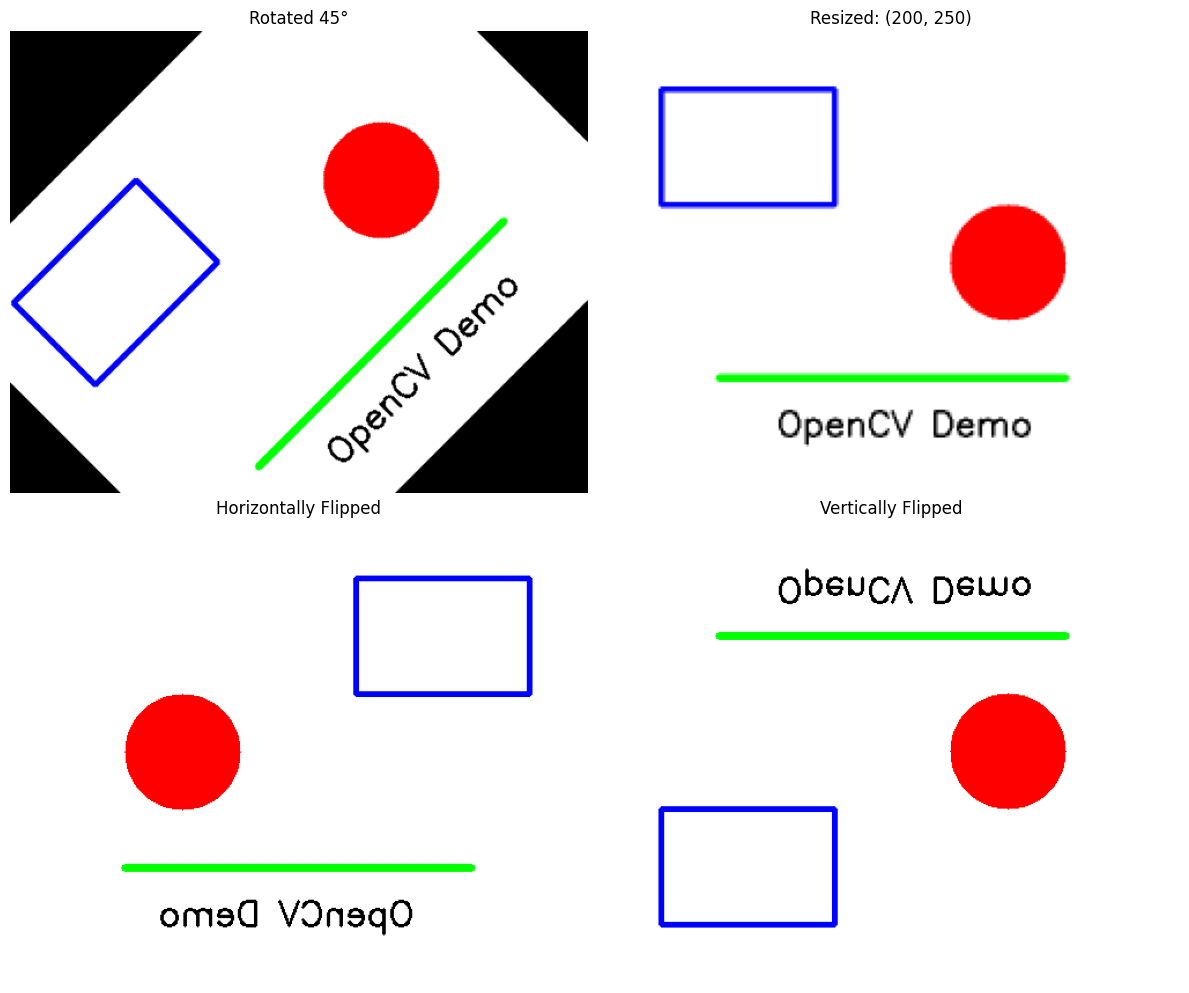

In [7]:
# 单元格7：显示附加操作结果
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Rotated 45°')
axes[0, 0].axis('off')

axes[0, 1].imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
axes[0, 1].set_title(f'Resized: {resized.shape[:2]}')
axes[0, 1].axis('off')

axes[1, 0].imshow(cv2.cvtColor(flipped_h, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title('Horizontally Flipped')
axes[1, 0].axis('off')

axes[1, 1].imshow(cv2.cvtColor(flipped_v, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title('Vertically Flipped')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

In [8]:
# 单元格8：保存所有处理结果
def save_all_images():
    """保存所有处理后的图像"""
    # 创建输出目录
    output_dir = 'processed_images'
    os.makedirs(output_dir, exist_ok=True)

    # 保存图像
    cv2.imwrite(f'{output_dir}/01_original.jpg', test_img)
    cv2.imwrite(f'{output_dir}/02_gray.jpg', gray_img)
    cv2.imwrite(f'{output_dir}/03_edges.jpg', edges)
    cv2.imwrite(f'{output_dir}/04_binary.jpg', binary)
    cv2.imwrite(f'{output_dir}/05_blurred.jpg', blurred)
    cv2.imwrite(f'{output_dir}/06_rotated.jpg', rotated)
    cv2.imwrite(f'{output_dir}/07_resized.jpg', resized)
    cv2.imwrite(f'{output_dir}/08_flipped_h.jpg', flipped_h)
    cv2.imwrite(f'{output_dir}/09_flipped_v.jpg', flipped_v)

    print(f"✓ All images saved to '{output_dir}' folder:")
    files = os.listdir(output_dir)
    for file in sorted(files):
        if file.endswith('.jpg'):
            file_path = os.path.join(output_dir, file)
            file_size = os.path.getsize(file_path) // 1024  # KB
            print(f"  - {file} ({file_size} KB)")

save_all_images()

✓ All images saved to 'processed_images' folder:
  - 01_original.jpg (15 KB)
  - 02_gray.jpg (11 KB)
  - 03_edges.jpg (14 KB)
  - 04_binary.jpg (11 KB)
  - 05_blurred.jpg (13 KB)
  - 06_rotated.jpg (30 KB)
  - 07_resized.jpg (6 KB)
  - 08_flipped_h.jpg (16 KB)
  - 09_flipped_v.jpg (15 KB)


In [9]:
# 单元格9：图像统计信息
print("=== Image Statistics ===")

def print_stats(image, name):
    """打印图像统计信息"""
    print(f"\n{name}:")
    print(f"  Shape: {image.shape}")
    print(f"  Data type: {image.dtype}")
    print(f"  Min value: {image.min()}")
    print(f"  Max value: {image.max()}")
    print(f"  Mean value: {image.mean():.2f}")

    if len(image.shape) == 2:  # 灰度图像
        print(f"  Std deviation: {image.std():.2f}")

print_stats(test_img, "Original Color Image")
print_stats(gray_img, "Grayscale Image")
print_stats(edges, "Edge Image")
print_stats(binary, "Binary Image")

=== Image Statistics ===

Original Color Image:
  Shape: (400, 500, 3)
  Data type: uint8
  Min value: 0
  Max value: 255
  Mean value: 242.47

Grayscale Image:
  Shape: (400, 500)
  Data type: uint8
  Min value: 0
  Max value: 255
  Mean value: 242.11
  Std deviation: 48.36

Edge Image:
  Shape: (400, 500)
  Data type: uint8
  Min value: 0
  Max value: 255
  Mean value: 3.79
  Std deviation: 30.87

Binary Image:
  Shape: (400, 500)
  Data type: uint8
  Min value: 0
  Max value: 255
  Mean value: 239.88
  Std deviation: 60.22


=== Interactive Demo ===
Testing different threshold values...
Threshold 100: White pixels = 188144
Threshold 127: White pixels = 188144
Threshold 150: White pixels = 186015
Threshold 200: White pixels = 186015


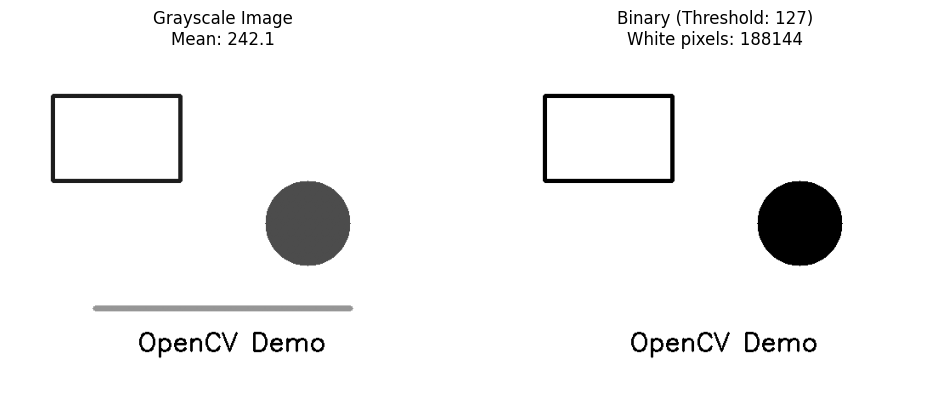

In [10]:
# 单元格10：简单的交互式处理
print("=== Interactive Demo ===")

# 创建一个函数来调整阈值
def adjust_threshold(threshold_value=127):
    """根据阈值调整二值化图像"""
    _, adjusted_binary = cv2.threshold(gray_img, threshold_value, 255, cv2.THRESH_BINARY)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(gray_img, cmap='gray')
    plt.title(f'Grayscale Image\nMean: {gray_img.mean():.1f}')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(adjusted_binary, cmap='gray')
    plt.title(f'Binary (Threshold: {threshold_value})\nWhite pixels: {np.sum(adjusted_binary > 0)}')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# 测试不同的阈值
print("Testing different threshold values...")
for thresh in [100, 127, 150, 200]:
    print(f"Threshold {thresh}: White pixels = {np.sum(cv2.threshold(gray_img, thresh, 255, cv2.THRESH_BINARY)[1] > 0)}")

# 显示一个示例
adjust_threshold(127)

In [11]:
# 单元格11：总结
print("=== Project Summary ===")
print("\n📊 What we accomplished:")
print("1. ✓ Created a test image with geometric shapes")
print("2. ✓ Converted color image to grayscale")
print("3. ✓ Applied edge detection using Canny")
print("4. ✓ Performed image thresholding (binary)")
print("5. ✓ Applied Gaussian blurring")
print("6. ✓ Rotated and resized the image")
print("7. ✓ Flipped image horizontally and vertically")
print("8. ✓ Saved all processed images to disk")
print("9. ✓ Displayed image statistics")

print("\n📁 Output files are in: 'processed_images' folder")
print(f"📍 Location: D:\\CV-Practice-Project\\processed_images")

print("\n🎯 Next steps you can try:")
print("  - Load your own images using cv2.imread('your_image.jpg')")
print("  - Try different edge detection parameters")
print("  - Experiment with color filtering")
print("  - Add text with different fonts and sizes")

print("\n✅ Simple OpenCV project completed successfully!")

=== Project Summary ===

📊 What we accomplished:
1. ✓ Created a test image with geometric shapes
2. ✓ Converted color image to grayscale
3. ✓ Applied edge detection using Canny
4. ✓ Performed image thresholding (binary)
5. ✓ Applied Gaussian blurring
6. ✓ Rotated and resized the image
7. ✓ Flipped image horizontally and vertically
8. ✓ Saved all processed images to disk
9. ✓ Displayed image statistics

📁 Output files are in: 'processed_images' folder
📍 Location: D:\CV-Practice-Project\processed_images

🎯 Next steps you can try:
  - Load your own images using cv2.imread('your_image.jpg')
  - Try different edge detection parameters
  - Experiment with color filtering
  - Add text with different fonts and sizes

✅ Simple OpenCV project completed successfully!


In [13]:
# 正确的验证代码
import os
import platform
import sys

print("=== 我正在哪里运行？ ===")
print(f"1. 操作系统: {platform.system()}")
print(f"2. 系统版本: {platform.version()}")
print(f"3. Python路径: {sys.executable}")
print(f"4. 当前目录: {os.getcwd()}")
print(f"5. 根目录内容:")

# 在Linux中，根目录是 /，不是D:\
try:
    # 尝试运行Linux命令
    import subprocess
    result = subprocess.run(['ls', '-la', '/'], capture_output=True, text=True)
    if result.returncode == 0:
        print("✅ 我在Linux/Docker容器中！")
        print(f"   根目录示例: {result.stdout.split()[0:5]}")
    else:
        print("❌ 这不是Linux环境")
except:
    print("❌ 无法执行Linux命令 - 我在Windows中")

=== 我正在哪里运行？ ===
1. 操作系统: Windows
2. 系统版本: 10.0.26200
3. Python路径: D:\Anoconda-dependency\envs_dirs\py-3-10\python.exe
4. 当前目录: D:\CV-Practice-Project
5. 根目录内容:
❌ 无法执行Linux命令 - 我在Windows中
